In [1]:
import pandas as pd
import yfinance as yf

In [2]:
calls = pd.read_csv("../data/options/SPY_Calls.csv")

In [3]:
spy = yf.Ticker("SPY")

spy_price = spy.history(period="1d")["Close"].iloc[-1]

print(f"Current SPY Price: {spy_price:.2f}")

Current SPY Price: 769.79


In [4]:
calls["Distance"] = abs(calls["strike"] - spy_price)

In [5]:
atm_option = calls.loc[calls["Distance"].idxmin()]

print(atm_option)

contractSymbol              SPY260806C00770000
lastTradeDate        2026-08-05 20:14:59+00:00
strike                                   770.0
lastPrice                                 2.74
bid                                        0.0
ask                                        0.0
change                                     0.0
percentChange                              0.0
volume                                 19182.0
openInterest                              6232
impliedVolatility                     0.001963
inTheMoney                               False
contractSize                           REGULAR
currency                                   USD
Distance                              0.210022
Name: 63, dtype: object


In [6]:
print(atm_option[
    [
        "strike",
        "lastPrice",
        "bid",
        "ask",
        "volume",
        "openInterest",
        "impliedVolatility",
        "inTheMoney"
    ]
])

strike                  770.0
lastPrice                2.74
bid                       0.0
ask                       0.0
volume                19182.0
openInterest             6232
impliedVolatility    0.001963
inTheMoney              False
Name: 63, dtype: object


In [7]:
calls = calls.sort_values("strike")

In [8]:
calls[
    [
        "strike",
        "impliedVolatility",
        "inTheMoney"
    ]
].head(15)

,strike,impliedVolatility,inTheMoney
0,630.0,0.00001,True
1,675.0,0.00001,True
2,680.0,0.00001,True
3,685.0,0.00001,True
4,700.0,0.00001,True
5,710.0,0.00001,True
6,712.0,0.00001,True
7,713.0,0.00001,True
8,715.0,0.00001,True
9,716.0,0.00001,True


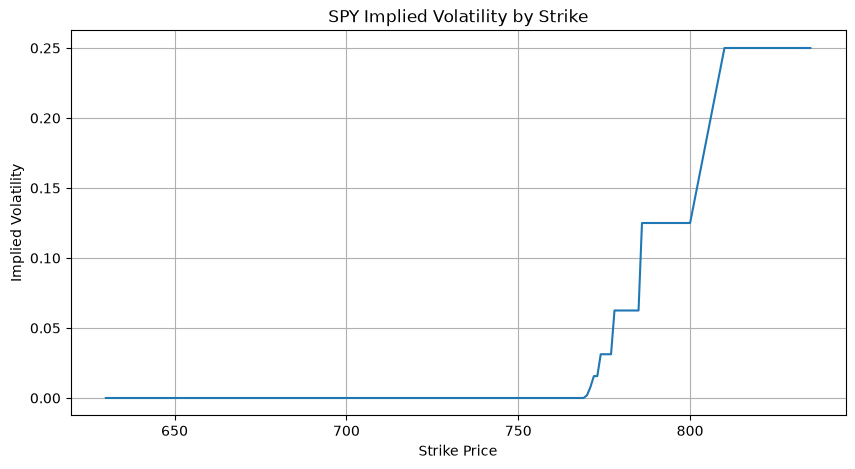

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    calls["strike"],
    calls["impliedVolatility"]
)

plt.title("SPY Implied Volatility by Strike")

plt.xlabel("Strike Price")

plt.ylabel("Implied Volatility")

plt.grid(True)

plt.show()

In [10]:
calls.to_csv(
    "../data/options/SPY_Calls_Filtered.csv",
    index=False
)